In [ ]:
#cspell:words backtest DEMA SUPERTREND
import config as cfg
import pandas as pd
import numpy as np
import indicators as ind
import data
import matplotlib.pyplot as plt

"""TODO SELL ON SUPERTREND FLIP"""

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


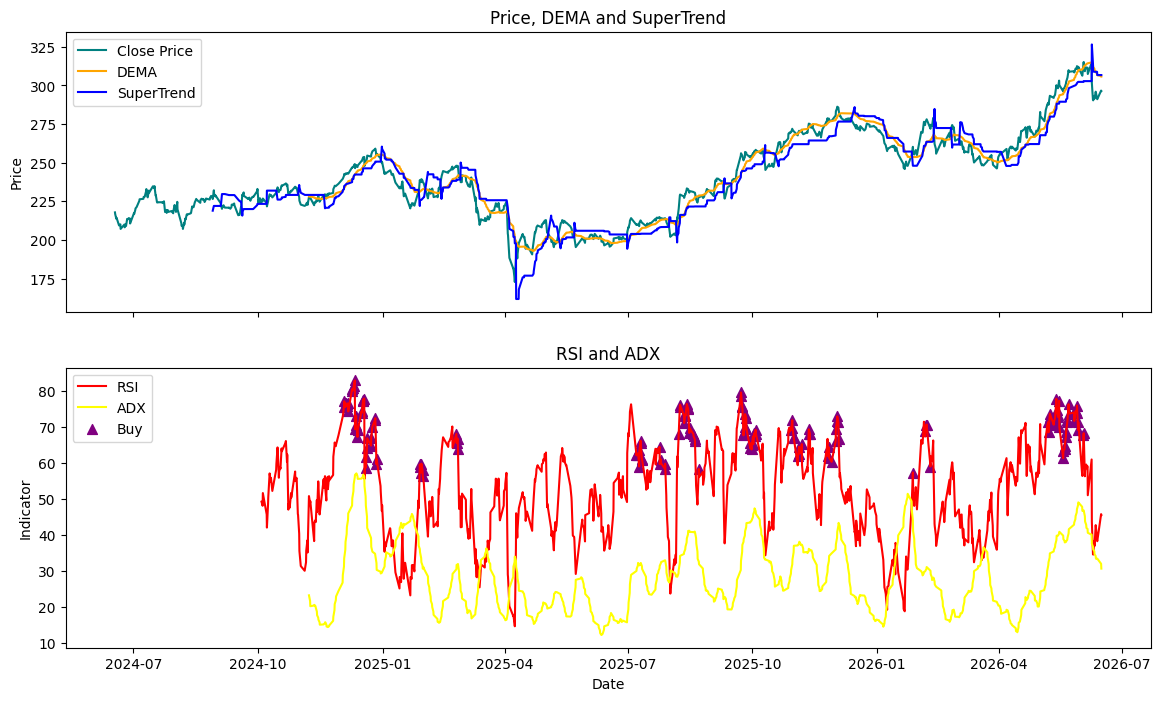

In [ ]:
import importlib

#cspell:words backtest DEMA xlabel ylabel sharex figsize
importlib.reload(cfg)
importlib.reload(ind)
importlib.reload(data)
df = data.df.dropna()

indicator_df = pd.DataFrame({
    'ATR': ind.ATR(df).calculate(),
    'SuperTrend': ind.SuperTrend(df).calculate(),
    'ADX': ind.ADX(df).calculate(),
    'RSI': ind.RSI(df).calculate(),
    'DEMA': ind.DEMA(df).calculate(),
}, index=df.index).interpolate(method='time', limit_area='inside')

In [32]:
#cspell:words Buy Sell DEMA RSI ADX ATR SuperTrend
df["Buy"] = (
    (df["Close"] > indicator_df["DEMA"]) &
    (indicator_df["RSI"] > 55) &
    (indicator_df["ADX"] > 30) &
    (indicator_df["ATR"] > 0) &
    (indicator_df["SuperTrend"] < df["Close"])
).fillna(False)

df["Sell"] = (
    (df["Close"] < indicator_df["DEMA"]) &
    (indicator_df["RSI"] < 45) &
    (indicator_df["ADX"] > 30) &
    (indicator_df["ATR"] > 0) &
    (indicator_df["SuperTrend"] > df["Close"])
).fillna(False)


In [ ]:
position = None
current_trade = None
trades = []

for row in df.itertuples():
    if row.Buy:
        if position == "Short":
            current_trade["Exit Date"] = row.Index
            current_trade["Exit Price"] = row.Close
            trades.append(current_trade)
            position = None
            current_trade = None

        if position != "Long":
            position = "Long"
            current_trade = {"Entry Date": row.Index, "Entry Price": row.Close, "Type": "Long"}

    elif row.Sell:
        if position == "Long":
            current_trade["Exit Date"] = row.Index
            current_trade["Exit Price"] = row.Close
            trades.append(current_trade)
            position = None
            current_trade = None

        if position != "Short":
            position = "Short"
            current_trade = {"Entry Date": row.Index, "Entry Price": row.Close, "Type": "Short"}

if current_trade is not None:
    current_trade["Exit Date"] = df.index[-1]
    current_trade["Exit Price"] = df["Close"].iloc[-1]
    trades.append(current_trade)

trades = pd.DataFrame(trades)


<Figure size 640x480 with 0 Axes>

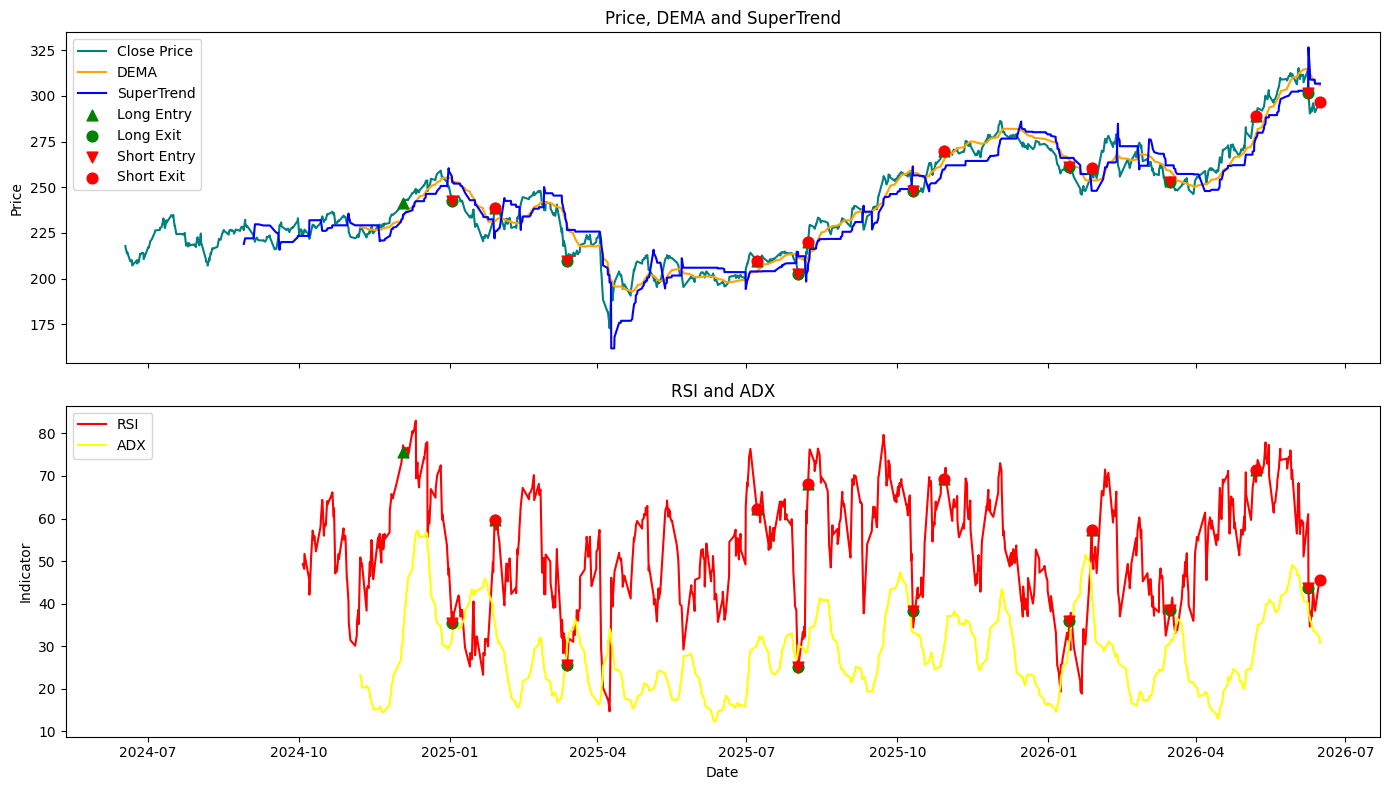

In [36]:
#cspell:words Buy Sell DEMA RSI ADX ATR SuperTrend sharex figsize ylabel, xlabel zorder
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

ax1.plot(df.index, df["Close"], label="Close Price", color="teal")
ax1.plot(indicator_df.index, indicator_df["DEMA"], label="DEMA", color="orange")
ax1.plot(indicator_df.index, indicator_df["SuperTrend"], label="SuperTrend", color="blue")
ax1.set_title("Price, DEMA and SuperTrend")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")

ax2.plot(indicator_df.index, indicator_df["RSI"], label="RSI", color="red")
ax2.plot(indicator_df.index, indicator_df["ADX"], label="ADX", color="yellow")

ax2.set_title("RSI and ADX")
ax2.set_ylabel("Indicator")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")

if not trades.empty:
    longs = trades[trades["Type"] == "Long"]
    shorts = trades[trades["Type"] == "Short"]

    if not longs.empty:
        ax1.scatter(longs["Entry Date"], longs["Entry Price"], marker="^", color="green", s=60, label="Long Entry", zorder=5)
        ax1.scatter(longs["Exit Date"], longs["Exit Price"], marker="o", color="green", s=60, label="Long Exit", zorder=5)
        ax2.scatter(longs["Entry Date"], indicator_df.loc[longs["Entry Date"], "RSI"], marker="^", color="green", s=60, label="Long Entry", zorder=5)
        ax2.scatter(longs["Exit Date"], indicator_df.loc[longs["Exit Date"], "RSI"], marker="o", color="green", s=60, label="Long Exit", zorder=5)

    if not shorts.empty:
        ax1.scatter(shorts["Entry Date"], shorts["Entry Price"], marker="v", color="red", s=60, label="Short Entry", zorder=5)
        ax1.scatter(shorts["Exit Date"], shorts["Exit Price"], marker="o", color="red", s=60, label="Short Exit", zorder=5)
        ax2.scatter(shorts["Entry Date"], indicator_df.loc[shorts["Entry Date"], "RSI"], marker="v", color="red", s=60, label="Short Entry", zorder=5)
        ax2.scatter(shorts["Exit Date"], indicator_df.loc[shorts["Exit Date"], "RSI"], marker="o", color="red", s=60, label="Short Exit", zorder=5)

    ax1.legend(loc="upper left")

plt.tight_layout()
plt.show()